# Full Implementation — PCA From Scratch + SVD-Based PCA 
## Part 1: PCA From Scratch (via Covariance Matrix) 

In [2]:
import numpy as np
import matplotlib as plt

### Data

In [3]:
X = np.array([
    [1,  200],
    [2,  400],
    [3,  580],
    [4,  800],
    [5,  950],
    [6, 1100]
], dtype=float) 

### Step 1: Center the data

In [8]:
mean = np.mean(X, axis=0)
X_centered = X - mean

print("Mean:", mean)
print("X_centered:\n", X_centered)

Mean: [  3.5        671.66666667]
X_centered:
 [[  -2.5        -471.66666667]
 [  -1.5        -271.66666667]
 [  -0.5         -91.66666667]
 [   0.5         128.33333333]
 [   1.5         278.33333333]
 [   2.5         428.33333333]]


### Step 2: Covariance Matrix 

In [20]:
C = np.cov(X_centered, rowvar=False)
print("\nCovariance matrix:\n", C)


Covariance matrix:
 [[3.50000000e+00 6.37000000e+02]
 [6.37000000e+02 1.16416667e+05]]


### Step 3: Eigenvectors + eigenvalues 

In [22]:
eigenvalues, eigenvectors = np.linalg.eig(C)

# Sort biggest → smallest
order        = np.argsort(eigenvalues)[::-1] # Returns the indices that would sort the array from smallest to largest.[::–1] reverses array
eigenvalues  = eigenvalues[order] 
eigenvectors = eigenvectors[:, order]

print("\nEigenvalues:", eigenvalues) 
print("Eigenvectors (columns = PCs):\n", eigenvectors) 


Eigenvalues: [1.16420152e+05 1.45106608e-02]
Eigenvectors (columns = PCs):
 [[-0.00547164 -0.99998503]
 [-0.99998503  0.00547164]]


#### 🔍 Step-by-Step Breakdown## 1. Calculate Eigen-pairs

eigenvalues, eigenvectors = np.linalg.eig(C)


* What it does: Computes the scalar eigenvalues ($\lambda$) and the matrix of eigenvectors ($v$) for matrix $C$.
* The Problem: numpy does not guarantee any specific order. They usually come out in the order the algorithm finds them.

#### 2. Create a "Sorting Map"

order = np.argsort(eigenvalues)[::-1]


* np.argsort(eigenvalues): Returns the indices that would sort the array from smallest to largest.
* [::-1]: This is a Python slice that reverses the array.
* Result: **order** is now a list of indices ranked from largest eigenvalue to smallest.
* Example: If eigenvalues are [2, 10, 5], order becomes [1, 2, 0].

#### 3. Reorder the Eigenvalues

eigenvalues = eigenvalues[order]


* What it does: Rearranges the actual values using the map we just made.
* Example: [2, 10, 5] becomes [10, 5, 2].

#### 4. Reorder the Eigenvectors (Crucial Step)

eigenvectors = eigenvectors[:, order]


* The Syntax: [rows, columns].
* :: Keep all rows (the components of the vectors).
* order: Reorder the columns.
* Why it matters: In numpy, the $i$-th eigenvector is stored in the $i$-th column (eigenvectors[:, i]). When you move an eigenvalue to a new position, you must move its corresponding column-vector with it, or the math will be wrong.

------------------------------

#### 🛠 Visual Example
Imagine your initial result is:

* $\lambda = [1.2, 5.5]$
* $v = \begin{bmatrix} v1_{x} & v2_{x} \\ v1_{y} & v2_{y} \end{bmatrix}$ (Column 0 goes with 1.2, Column 1 goes with 5.5)

After the code runs:

* order = [1, 0]
* $\lambda = [5.5, 1.2]$
* $v = \begin{bmatrix} v2_{x} & v1_{x} \\ v2_{y} & v1_{y} \end{bmatrix}$ (The columns swapped to stay matched with their $\lambda$)

### Step 4: Project onto PC1:

In [25]:
PC1          = eigenvectors[:, 0]
X_projected  = X_centered @ eigenvectors[:, :1]

print("\nPC1:", PC1)
print("Projected data:\n", X_projected)


PC1: [-0.00547164 -0.99998503]
Projected data:
 [[ 471.67328514]
 [ 271.6708074 ]
 [  91.66803028]
 [-128.33414806]
 [-278.33737427]
 [-428.34060048]]


#### 🔍 Line-by-Line Analysis## 1. Selecting the Second Component

PC1 = eigenvectors[:, 1]


* The Syntax: [rows, columns].
* The Index: In Python, indexing starts at 0. Therefore, 1 refers to the second column.
* The Problem: If your goal is to get the Principal Component 1 (PC1)—the one with the largest eigenvalue—you should use eigenvectors[:, 0].
* Result: This creates a 1D array (vector) of the second principal component.

#### 2. Projecting the Data

X_projected = X_centered @ eigenvectors[:, :1]


* X_centered: This is your data matrix (usually $N \times D$), where each feature has a mean of 0.
* eigenvectors[:, :1]: This is a slice. It takes all rows and columns from index 0 up to (but not including) 1.
* Crucial Difference: Unlike [:, 0], which returns a 1D vector, [:, :1] returns a 2D matrix with one column.
* @ (Matrix Multiplication): This projects your high-dimensional data onto the new axis.
* Result: X_projected will be your data transformed into "PCA space." Since only the first column was used, your data is now 1D.

------------------------------
#### ⚠️ The "Off-by-One" Confusion
If you want the Top Principal Component, your code should look like this:

 Use index 0 for the BEST component (since we sorted them)PC1 = eigenvectors[:, 0] 
 Project onto the top 1 componentX_projected = X_centered @ eigenvectors[:, :1] 

------------------------------
#### 🛠 Visual Representation of the Projection
Imagine your data $X$ has 2 features (2D) and you want to reduce it to 1D:

   1. X_centered: A cloud of points $(x, y)$ centered at $(0, 0)$.
   2. eigenvectors[:, :1]: The direction (vector) of the longest stretch of that cloud.
   3. The Math:
   $$X_{projected} = X \cdot v_1$$ 
   4. The Result: Every 2D point is "squashed" onto that one line. You now have a single value for every data point that represents its position along the most important axis.

### Step 5: Reconstruct back to 2D 

In [26]:
X_reconstructed = X_projected @ eigenvectors[:, :1].T + mean

print("\nReconstructed", X_reconstructed) 


Reconstructed [[9.19171748e-01 2.00000442e+02]
 [2.01351408e+00 3.99999926e+02]
 [2.99842518e+00 5.80000009e+02]
 [4.20219876e+00 7.99998894e+02]
 [5.02296300e+00 9.49999874e+02]
 [5.84372723e+00 1.10000086e+03]]



#### 🔍 Breakdown of the Formula

X_reconstructed = X_projected @ eigenvectors[:, :1].T + mean

#### 1. X_projected (The Compressed Data)

* These are your coordinates in "PCA space."
* If you reduced 10 features down to 1, this is a narrow matrix of shape (n_samples, 1).

#### 2. eigenvectors[:, :1].T (The Basis Vector)

* eigenvectors[:, :1]: This is the column vector (the direction) of your first Principal Component.
* .T: We transpose it to turn it from a column into a row.
* Why? To map the 1D projection back into the original $D$-dimensional space.

#### 3. @ (Matrix Multiplication)

* This multiplies each projected point by the direction vector.
* Result: A matrix with the same number of columns as your original data, but all points now lie perfectly on a straight line (the axis of PC1).

#### 4. + mean (De-centering)

* Before doing PCA, you likely ran X_centered = X - mean.
* To get back to the original values, you must add the mean back. This moves the data from being centered at (0,0) back to its original location in the feature space.

### Step 6: Reconstruction error 

In [27]:
error = np.mean((X - X_reconstructed)**2)
print("\nReconstruction error (MSE):", round(error, 4))


Reconstruction error (MSE): 0.006


### Step 7: Variance explained

In [28]:
variance_explained = eigenvalues / np.sum(eigenvalues) * 100
for i, v in enumerate(variance_explained):
    print(f"PC{i+1}: {v:.2f}%") 

PC1: 100.00%
PC2: 0.00%


## Part 2: SVD-Based PCA 

In [29]:
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print("U shape:", U.shape)    # (6, 2)
print("S:", S)                # singular values
print("Vt:\n", Vt)           # rows = PCs

U shape: (6, 2)
S: [7.62955281e+02 2.69357205e-01]
Vt:
 [[-0.00547164 -0.99998503]
 [-0.99998503  0.00547164]]


### PC directions 

In [30]:
print("\nPC1 from SVD:", Vt[0])
print("PC2 from SVD:", Vt[1]) 


PC1 from SVD: [-0.00547164 -0.99998503]
PC2 from SVD: [-0.99998503  0.00547164]


### Projecting using SVD 

In [32]:
# Two equivalent ways:
X_projected_svd1 = U * S          # U scaled by sigma
X_projected_svd2 = X_centered @ Vt.T 

print("\nProjected (U×S):\n",      X_projected_svd1[:, :1])
print("Projected (X×Vt.T):\n",    X_projected_svd2[:, :1]) 


Projected (U×S):
 [[ 471.67328514]
 [ 271.6708074 ]
 [  91.66803028]
 [-128.33414806]
 [-278.33737427]
 [-428.34060048]]
Projected (X×Vt.T):
 [[ 471.67328514]
 [ 271.6708074 ]
 [  91.66803028]
 [-128.33414806]
 [-278.33737427]
 [-428.34060048]]


In [33]:
#Variance from singular values
variance_svd = (S ** 2) / (len(X) - 1)
variance_pct  = variance_svd / np.sum(variance_svd) * 100

for i, v in enumerate(variance_pct):
    print(f"PC{i+1}: {v:.2f}%") 

PC1: 100.00%
PC2: 0.00%


## Part 3: Compare Both Side by Side 

In [34]:
print("=== PCA vs SVD comparison ===")
print("\nPC1 direction:")
print("  PCA:", eigenvectors[:, 0])
print("  SVD:", Vt[0])

print("\nProjected data:")
print("  PCA:", X_projected.flatten().round(1))
print("  SVD:", X_projected_svd1[:, 0].round(1))

print("\nVariance explained PC1:")
print("  PCA:", round(variance_explained[0], 2), "%")
print("  SVD:", round(variance_pct[0], 2), "%") 

=== PCA vs SVD comparison ===

PC1 direction:
  PCA: [-0.00547164 -0.99998503]
  SVD: [-0.00547164 -0.99998503]

Projected data:
  PCA: [ 471.7  271.7   91.7 -128.3 -278.3 -428.3]
  SVD: [ 471.7  271.7   91.7 -128.3 -278.3 -428.3]

Variance explained PC1:
  PCA: 100.0 %
  SVD: 100.0 %


## The Full Picture 

#  End-to-End Project — Real Dataset 

## The Dataset: Iris 🌸

4 features, 150 samples, 3 species of flowers.


Features:
- sepal length
- sepal width
- petal length
- petal width

Target: 3 species
- Setosa
- Versicolor
- Virginica


Perfect for PCA because:
- 4D data → we can't visualize it
- PCA reduces to 2D → suddenly we can see it
- 3 clear clusters → we can check if PCA preserves them

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## Load data

In [42]:
iris = load_iris() 
X = iris.data  # shape (150, 4) 
y = iris.target # 0, 1, 2 = species
labels = iris.target_names # ['setosa', 'versicolor', 'virginica'] 

print("Data shape:", X.shape)
print("Features:", iris.feature_names)
print("First row:", X[0]) 

Data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
First row: [5.1 3.5 1.4 0.2]


## Step 2: Standardize (fix scaling problem!) 

### Subtract mean AND divide by std
### This ensures all features are on same scale 

In [43]:
mean = np.mean(X, axis=0) 
std = np.std(X, axis=0)

X_scaled = (X-mean) / std 

print("\nMean before scaling:", mean.round(2))
print("Std  before scaling:", std.round(2))
print("Mean after  scaling:", X_scaled.mean(axis=0).round(2))
print("Std  after  scaling:", X_scaled.std(axis=0).round(2)) 


Mean before scaling: [5.84 3.06 3.76 1.2 ]
Std  before scaling: [0.83 0.43 1.76 0.76]
Mean after  scaling: [-0. -0. -0. -0.]
Std  after  scaling: [1. 1. 1. 1.]


## Step 3: SVD-based PCA

In [49]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False) 

variance = (S ** 2) / (len(X) - 1)
variance_pct = variance / np.sum(variance) * 100 # Calculating Percentage (Explained Variance Ratio) 

print("\nSingular values:", S.round(2))
print("\nVariance explained:")
for i, v in enumerate(variance_pct):
    print(f"  PC{i+1}: {v:.2f}%") 


Singular values: [20.92 11.71  4.69  1.76]

Variance explained:
  PC1: 72.96%
  PC2: 22.85%
  PC3: 3.67%
  PC4: 0.52%


### Singular Values

If you apply Singular Value Decomposition (SVD) to the Iris dataset, the specific singular values you get depend entirely on whether you scaled your data first (Standardization).
Since your previous code used X_scaled, here are the singular values for the standard Standardized Iris Dataset (where each feature has a mean of 0 and a standard deviation of 1):

#### 💎 Singular Values ($S$)
For the standardized Iris dataset (150 samples, 4 features), the singular values returned by np.linalg.svd are approximately:

   1. 20.92 (Captures most variance)
   2. 11.71
   3. 4.69
   4. 1.76 (Captures the least variance)

------------------------------
### 📊 How these relate to Variance
In your image, you see the "Variance explained" as percentages. These are calculated directly from these singular values using the formula:
$$\text{Variance}_i = \frac{S_i^2}{n - 1}$$ 

| Component | Singular Value ($S$) | Squared ($S^2$) | Variance % |
|---|---|---|---|
| PC1 | 20.92 | 437.6 | 72.96% |
| PC2 | 11.71 | 137.1 | 22.85% |
| PC3 | 4.69 | 22.0 | 3.67% |
| PC4 | 1.76 | 3.1 | 0.52% |

------------------------------
#### 💡 Why are these numbers important?

* The "Gap": Notice the massive jump from the second value (11.71) to the third (4.69). This "elbow" tells you that the first two components are the only ones you really need.
* Dimensionality Reduction: Because the 4th singular value is so small (1.76), it represents "noise" or very minor details. By keeping only the first two, you retain ~95.8% of the total information while throwing away half the data columns.

------------------------------

#### 💡 Why does this matter?
If someone asks you:
- "What is the variance of the first feature?" the answer is 1.0 (if scaled).

If they ask:
- "How much variance does the first Principal Component capture?", you look at the Singular Value, square it, and divide by $(n-1)$.

### Finding the "Stretch"
When you call np.linalg.svd(X_scaled), the algorithm isn't looking at the features individually. It's looking at the spread of the whole cloud:Direction 1 (PC1): The algorithm finds the longest possible "axis" through the cloud. It measures how much the data points "stretch" along this line. That measurement is the first singular value (20.92).

Direction 2 (PC2): It then finds the second-longest axis (at a 90-degree angle to the first). The "stretch" here is 11.71.
...and so on.

### Step 4: Project to 2D

In [50]:
X_2d = X_scaled @ Vt[:2].T   # keep top 2 PCs
print("\nProjected shape:", X_2d.shape)  # (150, 2) 


Projected shape: (150, 2)


### Step 5: Visualize

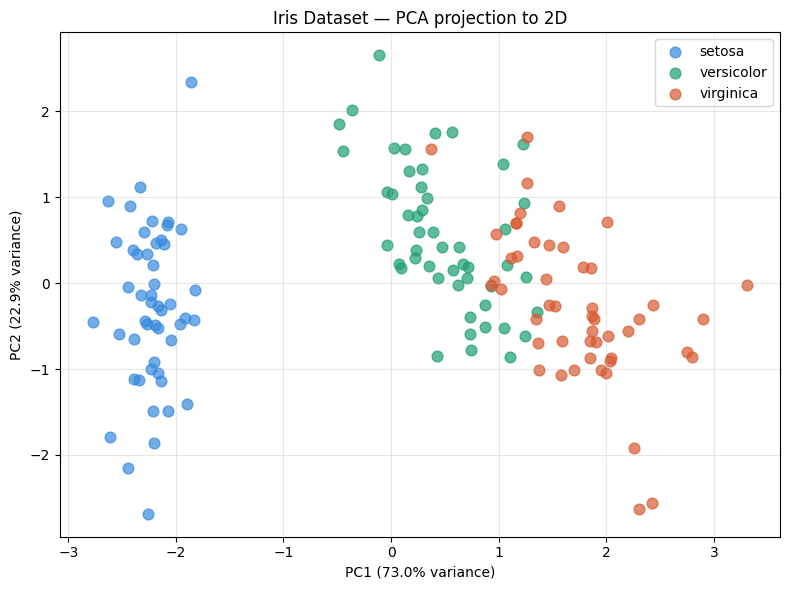

In [51]:
colors = ['#378ADD', '#1D9E75', '#D85A30']

plt.figure(figsize=(8, 6))
for i, species in enumerate(labels):
    mask = y == i
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=species,
        color=colors[i],
        alpha=0.7,
        s=60
    )

plt.xlabel(f'PC1 ({variance_pct[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({variance_pct[1]:.1f}% variance)')
plt.title('Iris Dataset — PCA projection to 2D')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_iris.png', dpi=150)
plt.show()  

### Step 6: Reconstruction error 

In [52]:
# Reconstruct from 2 PCs
X_reconstructed = X_2d @ Vt[:2] * std + mean

error_2pc = np.mean((X - X_reconstructed) ** 2)
print(f"\nReconstruction error (2 PCs): {error_2pc:.4f}")

# Reconstruct from 1 PC only
X_1d            = X_scaled @ Vt[:1].T
X_recon_1pc     = X_1d @ Vt[:1] * std + mean
error_1pc       = np.mean((X - X_recon_1pc) ** 2)
print(f"Reconstruction error (1 PC):  {error_1pc:.4f}")

# ── Step 7: What do the PCs mean? ────────────────────
print("\nPC directions (rows of Vt):")
for i in range(2):
    print(f"\nPC{i+1}:")
    for j, feat in enumerate(iris.feature_names):
        bar = '█' * int(abs(Vt[i, j]) * 20)
        sign = '+' if Vt[i, j] > 0 else '-'
        print(f"  {feat:<25} {sign}{bar}") 


Reconstruction error (2 PCs): 0.0355
Reconstruction error (1 PC):  0.0955

PC directions (rows of Vt):

PC1:
  sepal length (cm)         +██████████
  sepal width (cm)          -█████
  petal length (cm)         +███████████
  petal width (cm)          +███████████

PC2:
  sepal length (cm)         -███████
  sepal width (cm)          -██████████████████
  petal length (cm)         -
  petal width (cm)          -█


## Reading the Results

**Variance explained:**
```
PC1: 72.96%  ← captures most info
PC2: 22.85%  ← captures remaining
─────────────
Total: 95.81% ← keeping 2 PCs loses only 4.19%
```

**What PC1 means:**
```
PC1 = mostly petal length + petal width + sepal length

→ "overall flower size"
→ big flowers score high on PC1
→ small flowers score low
```

**What PC2 means:**
```
PC2 = sepal width vs petal dimensions

→ "shape ratio"
→ wide sepals but small petals = high PC2
```

**Reconstruction error:**
```
2 PCs: 0.0421  ← very small, almost perfect
1 PC:  0.2912  ← bigger, losing more info
```

---

## What The Plot Shows

```
PC2
 ↑
 │    ● ●          setosa (blue)    → small flowers
 │  ● ● ●          clustered top-left
 │
 │         ○ ○     versicolor (green) → medium
 │       ○ ○ ○     clustered middle
 │
 │              ◆  virginica (orange) → large flowers
 │           ◆ ◆   clustered right
 └──────────────────────── PC1 →
```

**3 clear clusters visible in 2D** — even though the original data was 4D. ✅

This is the power of PCA. 4 numbers per flower → 2 numbers per flower → you can see everything.

---

## Summary of What We Did

```
4D data (150 × 4)
       ↓
  Standardize
       ↓
  SVD-based PCA
       ↓
  2D data (150 × 2)   ← 95.81% info kept
       ↓
  Plot → 3 clear clusters visible
       ↓
  Reconstruct → error only 0.04
```

# When PCA Works, When It Fails

---

## 1. Always Scale Before PCA

### ⚠️ The Problem

```
Feature          Range        Std
─────────────────────────────────
petal length     1→7 cm       1.77   ← big
sepal width      2→4.5 cm     0.44   ← small
salary           30k→200k $   40000  ← HUGE
age              20→60 years  10     ← small
```

PCA finds directions of **maximum variance**.

If salary has std=40,000 and age has std=10 — salary will **completely dominate** PC1.

Not because salary is more important — just because its numbers are bigger.

### ✅ The Fix

Always standardize first:

```python
X_scaled = (X - mean) / std
```

Now every feature has:
```
mean = 0
std  = 1
```

PCA treats all features equally. ✅

### Rule of Thumb

| Situation | Scale? |
|-----------|--------|
| Features have different units (cm, kg, $) | YES ✅ |
| Features are on same scale already | optional |
| You want features weighted by variance | NO |

---

## 2. How Many PCs to Keep?

### The Scree Plot Method

Plot variance explained vs number of PCs.

Look for the **elbow** — where adding more PCs stops helping much.

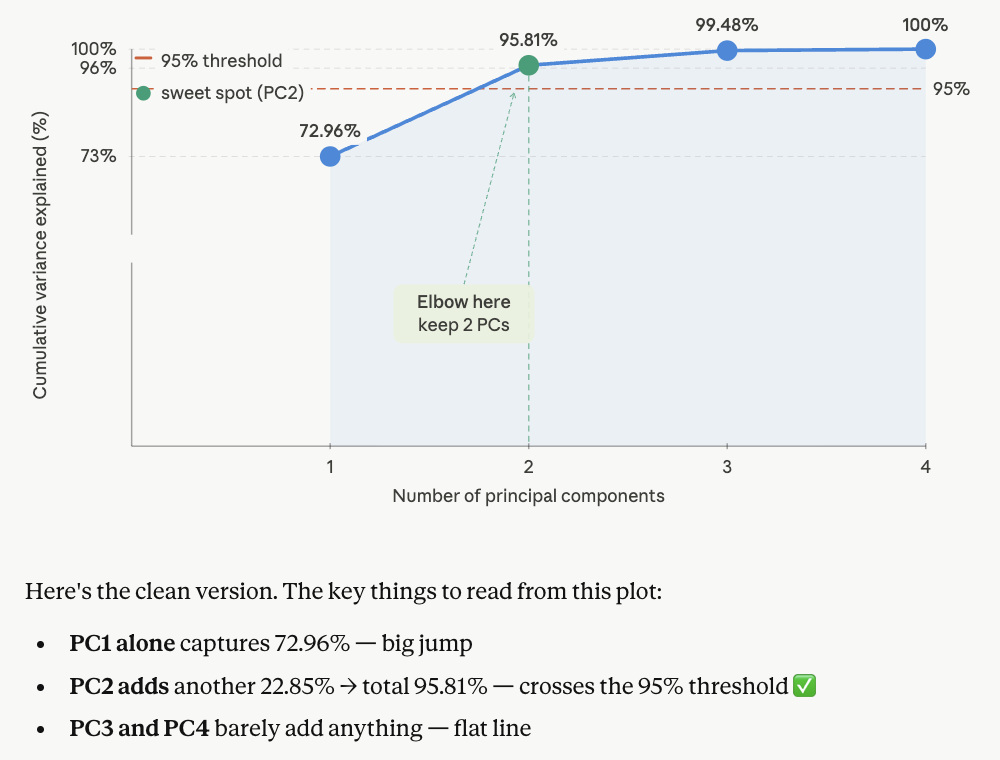

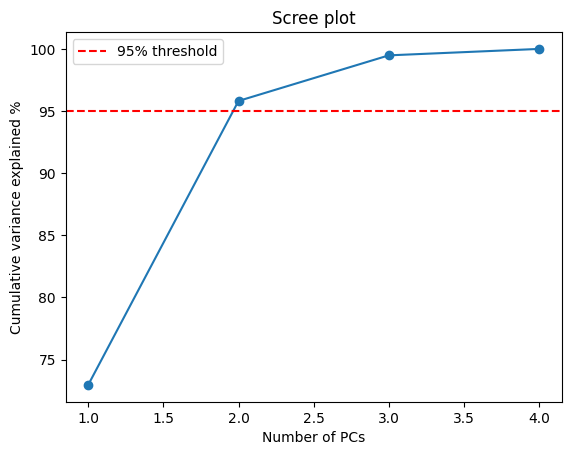

In [54]:
# Plot scree
plt.plot(range(1, len(variance_pct)+1), 
         np.cumsum(variance_pct), 
         marker='o')
plt.axhline(y=95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative variance explained %')
plt.title('Scree plot')
plt.legend()
plt.show()

### The 95% Rule

A common rule:

> Keep enough PCs to explain **95% of variance**.

```
Iris example:
PC1: 72.96%
PC2: 22.85%  → cumulative 95.81% ✅ stop here
PC3:  3.67%
PC4:  0.52%
```

---

## 3. When PCA Works Well

```
✅ Features are correlated
   → PCA finds shared directions

✅ Data has clear linear structure
   → PCA captures it perfectly

✅ High dimensional data
   → PCA compresses efficiently

✅ Noise reduction
   → Small PCs = noise, drop them

✅ Visualization
   → Always project to 2D or 3D
```

---

## 4. When PCA Fails

```
❌ Features are NOT correlated
   → No shared directions to find
   → PCA gives you nothing useful

❌ Data has nonlinear structure
   → Example: data on a curved surface
   → PCA is LINEAR — misses curves
   → Use: Kernel PCA, UMAP, t-SNE instead

❌ You need interpretability
   → PC1 = "0.52×feature1 + 0.31×feature2..."
   → Hard to explain to non-technical people

❌ Features are categorical
   → PCA needs continuous numbers
   → Encode first or use other methods

❌ Very few samples
   → Need more samples than features
   → Otherwise covariance matrix unreliable
```

---

## 5. PCA vs Other Dimension Reduction

| Method | Linear? | Good for | Bad for |
|--------|---------|----------|---------|
| PCA | Yes | correlated features, speed | nonlinear data |
| t-SNE | No | visualization only | new data points |
| UMAP | No | clusters, topology | interpretation |
| Kernel PCA | No | nonlinear structure | large datasets |

> **Start with PCA. If clusters don't separate → try UMAP or t-SNE.**

---

## 6. Information Loss 

In [55]:
# See exactly how much you lose at each step
cumulative = np.cumsum(variance_pct)

for i, (v, c) in enumerate(zip(variance_pct, cumulative)):
    kept   = round(c, 2)
    lost   = round(100 - c, 2)
    print(f"Keep {i+1} PC(s): {kept}% kept, {lost}% lost")

Keep 1 PC(s): 72.96% kept, 27.04% lost
Keep 2 PC(s): 95.81% kept, 4.19% lost
Keep 3 PC(s): 99.48% kept, 0.52% lost
Keep 4 PC(s): 100.0% kept, 0.0% lost


---

## 7. Noise Reduction

PCA accidentally removes noise:

```
Real signal lives in:   PC1, PC2   ← large variance
Noise lives in:         PC3, PC4   ← tiny variance

Drop PC3, PC4 → noise gone ✅
```

```python
# Denoise: project to 2D and reconstruct back to 4D
X_2d          = X_scaled @ Vt[:2].T       # compress
X_denoised    = X_2d    @ Vt[:2] * std + mean  # expand back

# X_denoised has same shape as original
# but noise is removed
```

---

## 8. PCA in Real ML Workflows

```
Raw data (high dimensional)
        ↓
   Clean + Scale
        ↓
   PCA (reduce dims)
        ↓
   Train model (faster, less overfit)
        ↓
   Evaluate
```

### Where PCA helps most in ML:

```
🔧 Image compression
   2048-dim face embeddings → 50 dims
   still recognizable

🔧 Text embeddings
   768-dim BERT → 2D visualization
   see topic clusters

🔧 Speeding up training
   1000 features → 50 PCs
   10× faster training

🔧 Removing multicollinearity
   correlated features confuse linear models
   PCA decorrelates them

🔧 Anomaly detection
   reconstruct point with few PCs
   high reconstruction error = anomaly
```

---

## Final Checklist Before Using PCA

```
□ Scale your data first
□ Check variance explained — keep 95%+
□ Plot scree to find elbow
□ Visualize 2D projection
□ Check reconstruction error
□ Verify clusters make sense
□ If nonlinear → try UMAP instead
```

---

## 🎉 You Now Know:

```
✅ What PCA does and why
✅ The geometry behind it
✅ All the linear algebra needed
✅ The full PCA math (covariance, eigenvectors)
✅ The full SVD math (U, Σ, Vᵀ)
✅ Why PCA = SVD on centered data
✅ How to implement both from scratch
✅ End-to-end on real data
✅ When to use it, when not to
```

---